In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cuda'

In [4]:
# Create dataset
materiales = pd.read_csv('./structuralparameters-vs-capacities-h2.csv')

In [5]:
materiales

,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,4.78,0.0157,312,840,15.71,4751,2692
1,3.23,0.0145,433,600,5.70,5445,1384
2,1.64,0.0122,728,320,4.65,3195,440
3,1.63,0.0134,813,440,4.71,2885,541
4,1.82,0.0136,733,460,4.77,3335,627
...,...,...,...,...,...,...,...
100,0.32,0.0072,2260,140,5.31,456,62
101,0.35,0.0044,1250,60,2.43,882,48
102,2.19,0.0125,559,500,5.79,3752,893
103,0.02,0.0004,1685,0,1.68,124,0


In [6]:
X = np.array(materiales.iloc[:, 2:], dtype=float)

In [7]:
y_gc = np.array(materiales.iloc[:, 0], dtype=float).reshape(-1,1)
y_vc = np.array(materiales.iloc[:, 1], dtype=float).reshape(-1,1)
y_gc.shape, y_vc.shape

((105, 1), (105, 1))

In [8]:
# Normalize the data
X_scaled = MinMaxScaler().fit_transform(X)
y_gc_scaled = MinMaxScaler().fit_transform(y_gc)
y_vs_scaled = MinMaxScaler().fit_transform(y_vc)

In [9]:
# Split the data into training and testing
X_train, X_test, y_gc_train, y_gc_test, y_vc_train, y_vc_test = train_test_split(X_scaled, y_gc_scaled, y_vs_scaled, test_size=0.33, random_state=42)

In [10]:
idx_train, idx_test = train_test_split(np.arange(X.shape[0]), test_size=1./3., random_state=42)

In [11]:
X_train, y_gc_train, y_vc_train= X_scaled[idx_train], y_gc_scaled[idx_train], y_vs_scaled[idx_train]
X_test, y_gc_test, y_vc_test = X_scaled[idx_test], y_gc_scaled[idx_test], y_vs_scaled[idx_test]
X_train.shape, X_test.shape, y_gc_train.shape, y_gc_test.shape, y_vc_train.shape, y_vc_test.shape

((70, 5), (35, 5), (70, 1), (35, 1), (70, 1), (35, 1))

In [12]:
class Data(Dataset):
  '''Dataset Class to store the samples and their corresponding labels, 
  and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.
  '''

  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:

    # need to convert float64 to float32 else 
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X.astype(np.float32)).to(device)
    self.y = torch.from_numpy(y.astype(np.float32)).to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [13]:
# Generate the training dataset
traindata_gc = Data(X_train, y_gc_train)
traindata_vc = Data(X_train, y_vc_train)

In [14]:
# Generate the test dataset
testdata_gc = Data(X_test, y_gc_test)
testdata_vc = Data(X_test, y_vc_test)

In [15]:
batch_size = 1
# tells the data loader instance how many sub-processes to use for data loading
# if the num_worker is zero (default) the GPU has to weight for CPU to load data
# Theoretically, greater the num_workers, 
# more efficiently the CPU load data and less the GPU has to wait
# num_workers = 32

# Load the training data into data loader with the 
# respective batch_size and num_workers
trainloader_gc = DataLoader(traindata_gc, batch_size=batch_size, shuffle=True)
trainloader_vc = DataLoader(traindata_vc, batch_size=batch_size, shuffle=True)

train_acc_loader_gc = DataLoader(traindata_gc, batch_size=len(traindata_gc))
train_acc_loader_vc = DataLoader(traindata_vc, batch_size=len(traindata_vc))

testloader_gc = DataLoader(testdata_gc, batch_size=len(testdata_gc))
testloader_vc = DataLoader(testdata_vc, batch_size=len(testdata_vc))

In [16]:
class LinearRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        '''The network has 4 layers
             - input layer
             - hidden layer
             - hidden layer
             - output layer
        '''
        super(LinearRegression, self).__init__()
        self.act = nn.ReLU()
        self.input_to_hidden = nn.Linear(in_features=input_dim, out_features=hidden_dim)
        self.hidden_layer_1 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.hidden_layer_2 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.hidden_to_output = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden(x))
        x = self.act(self.hidden_layer_1(x))
        x = self.act(self.hidden_layer_2(x))
        x = self.hidden_to_output(x)
        return x

In [17]:
# number of features (len of X cols)
input_dim = X_train.shape[1]
# number of hidden layers
hidden_layers = 10
# output dimension is 1 because of linear regression
output_dim = y_gc_train.shape[1]
# initiate the linear regression model
model_gc = LinearRegression(input_dim=input_dim, hidden_dim=hidden_layers, output_dim=output_dim).to(device)
print(model_gc)

LinearRegression(
  (act): ReLU()
  (input_to_hidden): Linear(in_features=5, out_features=10, bias=True)
  (hidden_layer_1): Linear(in_features=10, out_features=10, bias=True)
  (hidden_layer_2): Linear(in_features=10, out_features=10, bias=True)
  (hidden_to_output): Linear(in_features=10, out_features=1, bias=True)
)


In [18]:
summary(model=model_gc, input_data=(1,5))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 10]               60
├─ReLU: 1-2                              [-1, 1, 10]               --
├─Linear: 1-3                            [-1, 1, 10]               110
├─ReLU: 1-4                              [-1, 1, 10]               --
├─Linear: 1-5                            [-1, 1, 10]               110
├─ReLU: 1-6                              [-1, 1, 10]               --
├─Linear: 1-7                            [-1, 1, 1]                11
Total params: 291
Trainable params: 291
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 10]               60
├─ReLU: 1-2                              [-1, 1, 10]               --
├─Linear: 1-3                            [-1, 1, 10]               110
├─ReLU: 1-4                              [-1, 1, 10]               --
├─Linear: 1-5                            [-1, 1, 10]               110
├─ReLU: 1-6                              [-1, 1, 10]               --
├─Linear: 1-7                            [-1, 1, 1]                11
Total params: 291
Trainable params: 291
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [19]:
# criterion to computes the loss between input and target
criterion_gc = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer_gc = torch.optim.SGD(model_gc.parameters(), lr=0.1)

In [20]:
trainingloss_gc = []
testloss_gc = []

In [21]:
model_gc.eval()
X_acc_train_gc, y_acc_train_gc = next(iter(train_acc_loader_gc))
X_acc_test_gc, y_acc_test_gct = next(iter(testloader_gc))

In [22]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model_gc.train()
    for (inputs, labels) in trainloader_gc:
        # inputs, labels = data

        # forward propagation
        outputs = model_gc(inputs)
        loss = criterion_gc(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer_gc.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer_gc.step()
    model_gc.eval()
    #X_acc_train, y_acc_train = next(iter(train_acc_loader))
    trainingloss_gc.append(criterion_gc(model_gc(X_acc_train_gc), y_acc_train_gc).item())
    # X_acc_test, y_acc_test = next(iter(testloader))
    testloss_gc.append(criterion_gc(model_gc(X_acc_test_gc), y_acc_test_gct).item())  

100%|█████████████████████████████████████████| 100/100 [00:06<00:00, 15.72it/s]


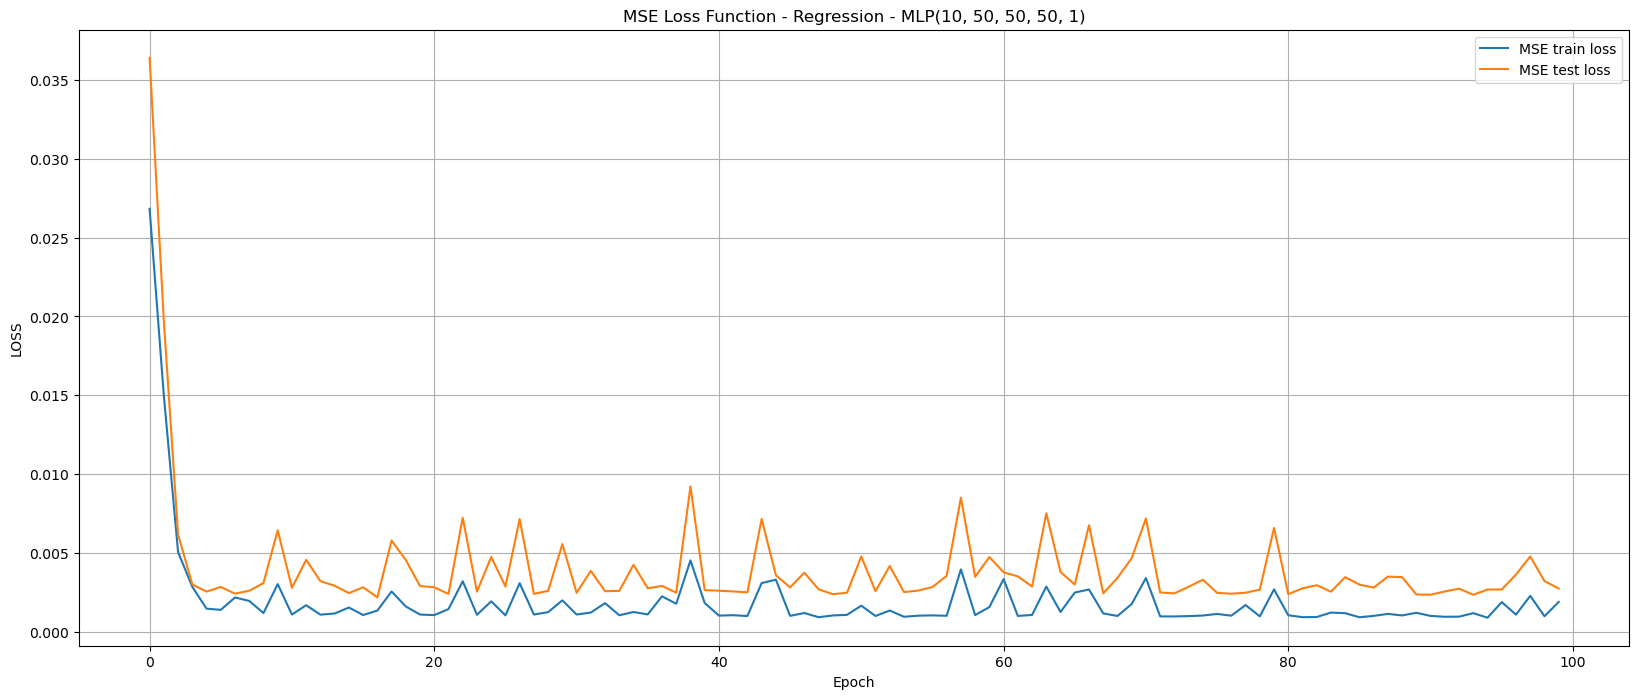

In [23]:
fig, ax = plt.subplots(figsize=(20,8))


ax.plot(trainingloss_gc, label='MSE train loss')
ax.plot(testloss_gc, label='MSE test loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('LOSS')
ax.legend()
ax.grid()
ax.set_title("MSE Loss Function - Regression - MLP(10, 50, 50, 50, 1)")

plt.show()

In [24]:
for x in model_gc.parameters():
    x.requires_grad = False

In [25]:
entrada = torch.rand(5, requires_grad = True).to(device)

In [26]:
entrada_min = torch.zeros_like(entrada)
entrada_max = torch.ones_like(entrada)

In [27]:
torch.min(torch.vstack((entrada, entrada_max)), dim=0)[0]

tensor([0.4950, 0.4269, 0.0335, 0.1232, 0.1112], device='cuda:0',
       grad_fn=<MinBackward0>)

In [28]:
torch.max(torch.vstack((entrada, entrada_min)), dim=0)

torch.return_types.max(
values=tensor([0.4950, 0.4269, 0.0335, 0.1232, 0.1112], device='cuda:0',
       grad_fn=<MaxBackward0>),
indices=tensor([0, 0, 0, 0, 0], device='cuda:0'))

In [29]:
epsilon = torch.tensor(0.0001, dtype=torch.float32, device=device)
iterations = 10000

In [38]:
for t in tqdm(range(iterations)):
    entrada.retain_grad()
    loss = criterion_gc(model_gc(entrada), torch.tensor([0.5], dtype=torch.float32).to(device))
    loss.backward()
    
    entrada -= epsilon*entrada.grad
    entrada[entrada > 1.] = torch.ones_like(entrada[entrada > 1.])
    entrada[entrada < 0.] = torch.zeros_like(entrada[entrada < 0.])
    if torch.abs(model_gc(entrada)- 0.5).item() < epsilon:
        print(model_gc(entrada), entrada)
        break;

  0%|                                         | 1/10000 [00:00<02:39, 62.64it/s]


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [32]:
with torch.no_grad():
        entrada = torch.min(torch.vstack((entrada, entrada_max)), dim=0)[0]
        entrada = torch.max(torch.vstack((entrada, entrada_min)), dim=0)[0]

    entrada.requires_grad_()
    # print(type(salida.item()))

IndentationError: unindent does not match any outer indentation level (<string>, line 5)

In [34]:
entrada[entrada > 1.] = torch.ones_like(entrada[entrada > 1.])

In [37]:
entrada

tensor([1., 1., 1., 0., 0.], device='cuda:0', grad_fn=<IndexPutBackward0>)

In [36]:
entrada[entrada < 0.] = torch.zeros_like(entrada[entrada < 0.])